# Ropedia Academy — C4 · Action recognition & anticipation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/C4.ipynb)

> **Implements recognition and anticipation, then plots the next-action probability distribution with the top-5 set and the ground-truth action highlighted.**
>
> 实现识别与预判，并画出下一动作的概率分布，高亮 top-5 集合与真实动作。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/C4

recognized (verb,noun): (4, 4)
top-5 next actions: [1, 6, 2, 15, 19] | true in top-5: False


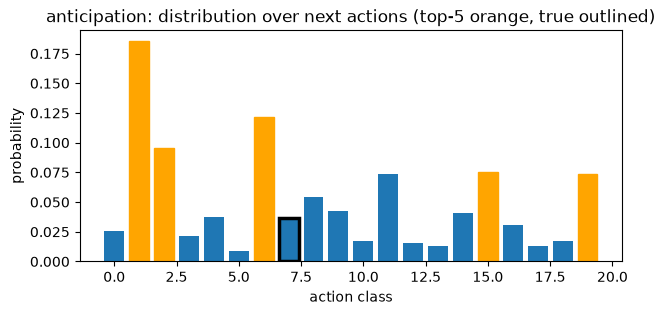

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, matplotlib.pyplot as plt
# Recognition (now) vs anticipation (next, multi-modal -> top-k).

# ---------- INPUT: one clip's features + the true next action ----------
feat = torch.randn(1, 512)
true_next = 7

# ---------- MODEL: (verb,noun) heads + a next-action distribution ----------
verb, noun = nn.Linear(512,5)(feat).argmax(-1).item(), nn.Linear(512,10)(feat).argmax(-1).item()
probs = F.softmax(nn.Linear(512, 20)(feat), -1)[0]
top5 = probs.topk(5).indices.tolist()

# ---------- OUTPUT: predictions + the next-action distribution (top-5/true) ----------
print("recognized (verb,noun):", (verb, noun))
print("top-5 next actions:", top5, "| true in top-5:", true_next in top5)
plt.figure(figsize=(7, 3))
bars = plt.bar(range(20), probs.detach())
for i in top5: bars[i].set_color('orange')
bars[true_next].set_edgecolor('k'); bars[true_next].set_linewidth(2.5)
plt.title("anticipation: distribution over next actions (top-5 orange, true outlined)")
plt.xlabel("action class"); plt.ylabel("probability"); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/C4
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks